In [ ]:
!pip install --user tensorflow scikit-learn pandas numpy matplotlib seaborn

In [1]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Load Boston Housing Dataset
boston = tf.keras.datasets.boston_housing

(x_train, y_train), (x_test, y_test) = boston.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
(404, 13) (404,)
(102, 13) (102,)


In [3]:
# Feature Scaling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.reshape(-1, 1))

In [4]:
# Build Deep Learning Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(13,), name='input-layer'),

    tf.keras.layers.Dense(100, name='hidden-layer-2'),

    tf.keras.layers.BatchNormalization(name='hidden-layer-3'),

    tf.keras.layers.Dense(50, name='hidden-layer-4'),

    tf.keras.layers.Dense(1, name='output-layer')
])

In [5]:
# Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden-layer-2 (Dense)               │ (None, 100)                 │           1,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden-layer-3 (BatchNormalization)  │ (None, 100)                 │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden-layer-4 (Dense)               │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output-layer (Dense)                 │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,901 (26.96 KB)

 Trainable params: 6,701 (26.18 KB)

 Non-trainable params: 200 (800.00 B)

In [6]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [7]:
# Train Model
history = model.fit(
    x_train_scaled,
    y_train_scaled,
    batch_size=32,
    epochs=20,
    validation_data=(x_test_scaled, y_test_scaled)
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 2.0071 - mae: 0.9375 - val_loss: 0.4928 - val_mae: 0.5109
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5644 - mae: 0.5603 - val_loss: 0.5595 - val_mae: 0.5334
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4847 - mae: 0.4941 - val_loss: 0.5799 - val_mae: 0.5490
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4132 - mae: 0.4757 - val_loss: 0.4618 - val_mae: 0.4783
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3613 - mae: 0.4331 - val_loss: 0.4733 - val_mae: 0.4855
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3200 - mae: 0.4081 - val_loss: 0.4332 - val_mae: 0.4609
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3642 - mae: 0.4359 - val_loss: 0.4834 - val_mae: 0.4917
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3534 - mae: 0.4357 - val_loss: 0.4543 - val_mae: 0.4798
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.357

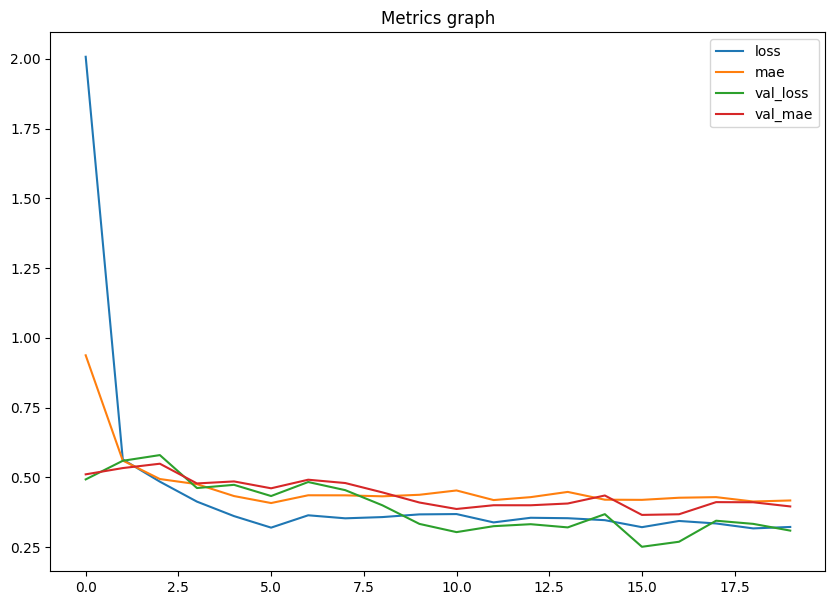

In [8]:
# Plot Metrics Graph
pd.DataFrame(history.history).plot(figsize=(10, 7))

plt.title("Metrics graph")
plt.show()

In [9]:
# Prediction
y_pred_scaled = model.predict(x_test_scaled)

# Convert back to original scale
y_pred = scaler.inverse_transform(y_pred_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


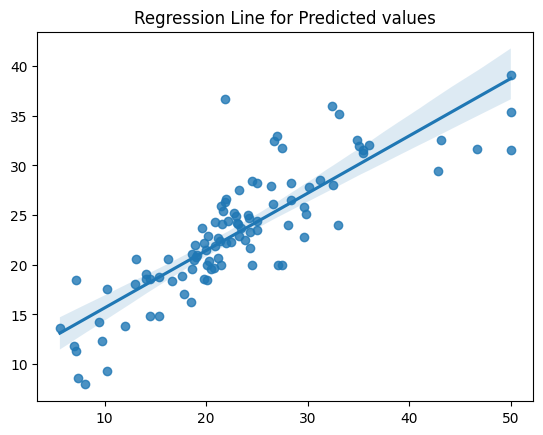

In [10]:
# Regression Plot
sns.regplot(x=y_test, y=y_pred)

plt.title("Regression Line for Predicted values")
plt.show()

In [11]:
# Evaluation Metrics
def regression_metrics_display(y_test, y_pred):

    print("MAE is", metrics.mean_absolute_error(y_test, y_pred))

    print("MSE is", metrics.mean_squared_error(y_test, y_pred))

    print("R2 score is", metrics.r2_score(y_test, y_pred))


regression_metrics_display(y_test, y_pred)

MAE is 3.6422721647748757
MSE is 26.176215527152735
R2 score is 0.6855477492618982
